In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb
import lightgbm as lgb



In [2]:
#load the data
X_train = pd.read_csv('/home/hossamhamdy/AI_Portfolio/Project_01_House_Price_Prediction/data/X_train_processed.csv')
y = pd.read_csv('/home/hossamhamdy/AI_Portfolio/Project_01_House_Price_Prediction/data/y_train.csv').squeeze() 



In [3]:
# evaluation function
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def rmse_cv(model):
    scores = -cross_val_score(
        model, X_train, y,
        scoring='neg_root_mean_squared_error',
        cv=kf
    )
    return scores.mean()

In [4]:
# fine tune Ridge model
def objective_ridge(trial):
    alpha = trial.suggest_float('alpha', 0.1, 100.0, log=True)
    
    model = Pipeline([
        ('scaler', RobustScaler()),
        ('model', Ridge(alpha=alpha))
    ])
    
    return rmse_cv(model)

# Run optimization
study_ridge = optuna.create_study(direction='minimize')
study_ridge.optimize(objective_ridge, n_trials=50)

print(f"Best Ridge RMSE: {study_ridge.best_value:.4f}")
print(f"Best Ridge params: {study_ridge.best_params}")

Best Ridge RMSE: 0.1119
Best Ridge params: {'alpha': 10.412953656318917}


In [5]:
#fine tune LightGBM model
def objective_lgb(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'num_leaves':        trial.suggest_int('num_leaves', 20, 100),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    
    model = lgb.LGBMRegressor(**params)
    return rmse_cv(model)

study_lgb = optuna.create_study(direction='minimize')
study_lgb.optimize(objective_lgb, n_trials=100)

print(f"Best LightGBM RMSE: {study_lgb.best_value:.4f}")
print(f"Best LightGBM params: {study_lgb.best_params}")

Best LightGBM RMSE: 0.1192
Best LightGBM params: {'n_estimators': 690, 'learning_rate': 0.02011820620908632, 'max_depth': 6, 'num_leaves': 57, 'min_child_samples': 39, 'subsample': 0.506821746158421, 'colsample_bytree': 0.5051642633258705, 'reg_alpha': 0.0005712165849266721, 'reg_lambda': 0.002714338283287307}


In [6]:
#fine tune XGBoost model
def objective_xgb(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':         trial.suggest_int('max_depth', 3, 8),
        'min_child_weight':  trial.suggest_int('min_child_weight', 1, 10),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1
    }
    
    model = xgb.XGBRegressor(**params)
    return rmse_cv(model)

study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=100)

print(f"Best XGBoost RMSE: {study_xgb.best_value:.4f}")
print(f"Best XGBoost params: {study_xgb.best_params}")

Best XGBoost RMSE: 0.1140
Best XGBoost params: {'n_estimators': 953, 'learning_rate': 0.017121448472152242, 'max_depth': 4, 'min_child_weight': 2, 'subsample': 0.500292621295294, 'colsample_bytree': 0.526591163035804, 'reg_alpha': 0.003351561224939414, 'reg_lambda': 0.0002343004339290042}


In [9]:
# Compare Tuned vs Untuned models
baseline = {
    'Ridge':     0.1119,
    'LightGBM':  0.1233,
    'XGBoost':   0.1207,
}

# Tuned results
tuned = {
    'Ridge (tuned)':    study_ridge.best_value,
    'LightGBM (tuned)': study_lgb.best_value,
    'XGBoost (tuned)':  study_xgb.best_value,
}

print("=" * 45)
print(f"{'Model':<25} {'RMSE':>10} {'Improvement':>10}")
print("=" * 45)

for model in ['Ridge', 'LightGBM', 'XGBoost']:
    base = baseline[f'{model}']
    
    tune = tuned[f'{model} (tuned)']
    
    improvement = (base - tune) / base * 100
    
    print(f"{model:<25} {tune:>10.4f} {improvement:>9.1f}%")

print("=" * 45)

Model                           RMSE Improvement
Ridge                         0.1119       0.0%
LightGBM                      0.1192       3.4%
XGBoost                       0.1140       5.5%


In [11]:
# Build final models with best parameters
best_ridge = Pipeline([
    ('scaler', RobustScaler()),
    ('model', Ridge(**study_ridge.best_params))
])

best_lgb = lgb.LGBMRegressor(
    **study_lgb.best_params,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

best_xgb = xgb.XGBRegressor(
    **study_xgb.best_params,
    random_state=42,
    n_jobs=-1
)


In [12]:
# Train on full training data
print("Training final tuned models...")
best_ridge.fit(X_train, y)
best_lgb.fit(X_train, y)
best_xgb.fit(X_train, y)

Training final tuned models...


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.526591163035804
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import 

In [13]:
# Load test data
X_test = pd.read_csv('/home/hossamhamdy/AI_Portfolio/Project_01_House_Price_Prediction/data/X_test_processed.csv')
test = pd.read_csv("/home/hossamhamdy/AI_Portfolio/Project_01_House_Price_Prediction/data/test.csv")
test_ID = test['Id']


In [14]:
# predictions
ridge_pred = best_ridge.predict(X_test)
lgb_pred   = best_lgb.predict(X_test)
xgb_pred   = best_xgb.predict(X_test)

In [15]:
# Weighted blend
final_pred = (0.2 * ridge_pred +
              0.4 * lgb_pred +
              0.4 * xgb_pred)

In [16]:
final_prices = np.expm1(final_pred)
submission = pd.DataFrame({
    'Id': test_ID,
    'SalePrice': final_prices
})
submission.to_csv('/home/hossamhamdy/AI_Portfolio/Project_01_House_Price_Prediction/results/submission_tuned.csv', index=False)

print(submission['SalePrice'].describe())

count      1459.000000
mean     178041.264277
std       76919.657464
min       46539.837856
25%      127909.209667
50%      156484.309091
75%      209397.330000
max      643240.370353
Name: SalePrice, dtype: float64


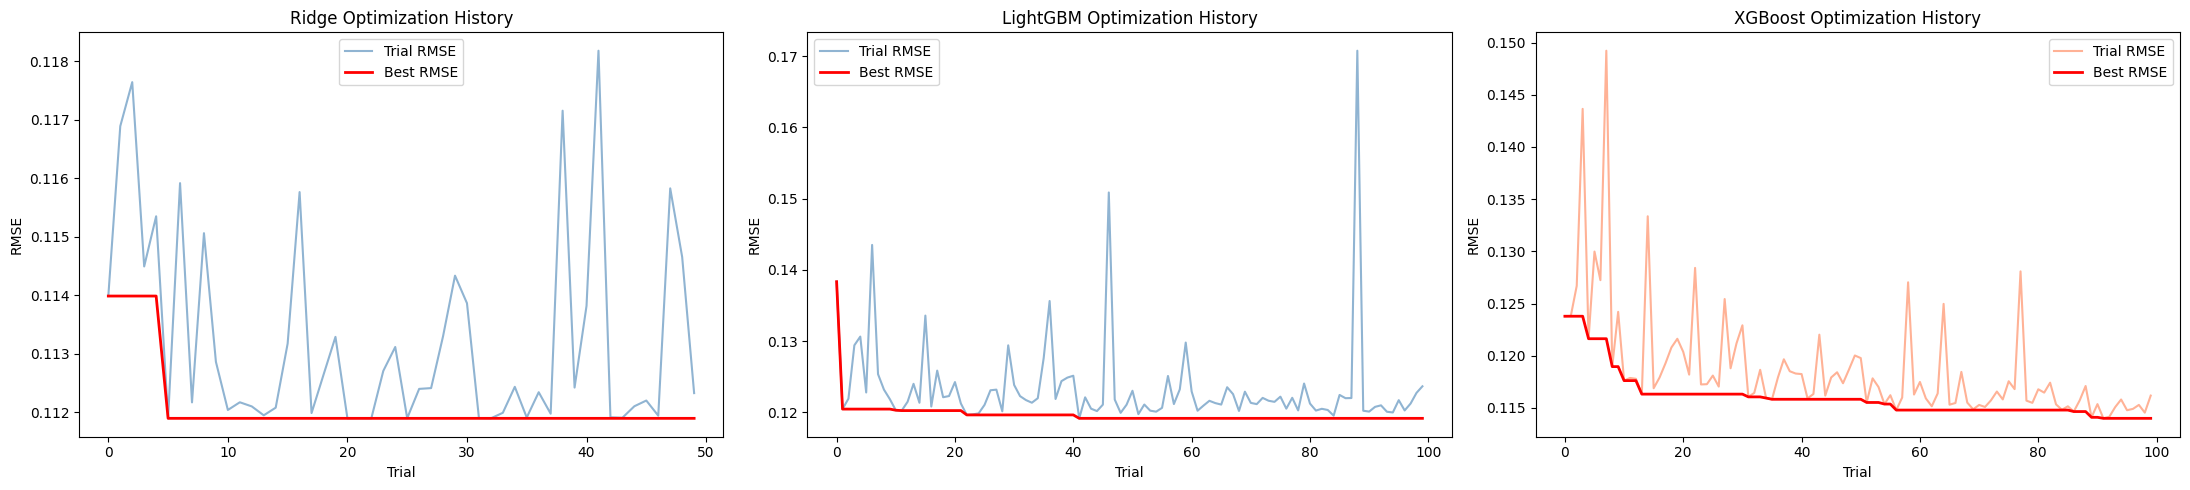

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(22, 5))

# Ridge optimization history
ridge_values = [t.value for t in study_ridge.trials]
axes[0].plot(ridge_values, color='steelblue', alpha=0.6, label='Trial RMSE')
axes[0].plot(pd.Series(ridge_values).cummin(),
             color='red', linewidth=2, label='Best RMSE')
axes[0].set_title('Ridge Optimization History')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('RMSE')
axes[0].legend()

# LightGBM optimization history
lgb_values = [t.value for t in study_lgb.trials]
axes[1].plot(lgb_values, color='steelblue', alpha=0.6, label='Trial RMSE')
axes[1].plot(pd.Series(lgb_values).cummin(),
             color='red', linewidth=2, label='Best RMSE')
axes[1].set_title('LightGBM Optimization History')
axes[1].set_xlabel('Trial')
axes[1].set_ylabel('RMSE')
axes[1].legend()

# XGBoost optimization history
xgb_values = [t.value for t in study_xgb.trials]
axes[2].plot(xgb_values, color='coral', alpha=0.6, label='Trial RMSE')
axes[2].plot(pd.Series(xgb_values).cummin(),
             color='red', linewidth=2, label='Best RMSE')
axes[2].set_title('XGBoost Optimization History')
axes[2].set_xlabel('Trial')
axes[2].set_ylabel('RMSE')
axes[2].legend()

plt.tight_layout()
plt.savefig('/home/hossamhamdy/AI_Portfolio/Project_01_House_Price_Prediction/results/optuna_history.png', dpi=150, bbox_inches='tight')
plt.show()